<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">Datos Masivos II · PRÁCTICA 1</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Sección Dos: Hojas de Tomate</div><div style="opacity:.72;font-size:14px;margin-top:6px;margin-bottom:10px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div><img src="https://mmss.iimas.unam.mx/dmmss/wp-content/uploads/2026/02/cropped-LogoUNAM_IIMAS_Negro50-scaled-2.png" width="200"/></div>

## Instrucciones 
Realizar una comparación entre: PCA, Non Negative Matrix y TSNE con los conjuntos de datos dados, así como una visualización de estos. 
Además, generar un clasificador o identificación de patrones, según sea el caso.

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Contexto. Clasificación de Hojas de Tomate: Identificación de infecciones en huerta. </span></div>

La presencia de plagas en u otras enfermedades en huertos puede llegar a tener un impacto significativo en producción y calidad, que se ve reflejado en un desabasto de alimentos para una pobolación. En búsqueda de solucionar esta problemática, utilizaremos la base de datos proporcionada, que se divide en dos conjuntos de datos de imágenes de hojas de tomate según diferentes fuentes. Las imágenes de hojas de tomate del primer conjunto de datos se seleccionaron de la base de datos `PlantVillage` con diez categorías (nueve categorías de **enfermedades** y una de **salud**). Las categorías detalladas del primer conjunto de datos son:
1. Mancha bacteriana,
2. Tizón temprano,
3. Saludable,
4. Tizón tardío,
5. Moho foliar,
6. Mancha foliar por Septoria,
7. Mancha diana,
8. Virus del mosaico del tomate,
9. Virus del rizado amarillo de la hoja del tomate,
10. Araña de dos manchas

El segundo conjunto de datos son imágenes de hojas de tomate de Taiwán, con seis categorías (cinco de **enfermedades** y una de **salud**). Incluye imágenes de una sola hoja, varias hojas, un fondo simple y un fondo complejo, con registros sintéticos creados a través de un método de aumento de datos para incrementar el número de imágenes. Tras la mejora de datos, se obtuvieron 4976 imágenes. Las categorías detalladas del segundo conjunto de datos son:
1. Mancha bacteriana,
2. Moho negro de la hoja,
3. Mancha gris de la hoja,
4. Sano,
5. Tizón tardío,
6. Oídio

Al realizar un aplanado, se obtienen instancias con **51,529 dimensiones**, que hace poco eficiente analizar una gran cantidad de información. Por ende, para facilitar la detección oportuna de enfermedades, se implementarán los algoritmos de reducción de dimensionalidad vistos en clase para disminuir la cantidad de atributos y se evaluará un clasificador para verificar la efectividad de la reducción.

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.1 Los Datos </span></div>

* `plant_village`: Conjunto de datos que cuenta con las 10 categorías originales en imágenes de dimensión $227\times227$. Contiene dos carpetas: `5 cross-validation`, con las imágenes ya divididas para validación cruzada de 5 pliegues, y `Preprocessed data`, con las imágenes preprocesadas antes de la división.
* `taiwan`: Conjunto con 6 categorías, de 662 imágenes originales (presentes y divididas en `Preprocessed data`) y 4976 totales (tras generar datos sintéticos, presentes y divididas en `data augmentation`).

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.2 Preparación de Entorno  </span></div>

In [1]:
# Importación de Bibliotecas

# Rutas y acceso a carpetas
import os
from pathlib import Path

# Manejo de datos
import pandas as pd
import numpy as np
import math as mt

# Visualización
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import seaborn as sns

# Escalado y separación
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Reducción de dimensionalidad
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE

In [2]:
def perfilar_dataset_imagenes(ruta_base):
    """ 
    Función que escanea los archivos y devuelve un resumen en metadatos de todas las imágenes dentro del repositorio.

    Args:
        ruta_base (str): Dirección de la carpeta donde están presentes las imágenes.

    Returns:
        df_meta (pd.DataFrame): DataFrame con información general de las imágenes, como tamaño, etiqueta, peso, ruta
                                completa, etcétera.
    """
    metadatos = []
    ruta_path = Path(ruta_base)
    extensiones_validas = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    for ruta_img in ruta_path.rglob('*'):
        if ruta_img.suffix.lower() in extensiones_validas:
            categoria = ruta_img.parent.name
            try:
                with Image.open(ruta_img) as img:
                    ancho, alto = img.size
                    modo = img.mode
                    canales = len(img.getbands())
                    peso_kb = os.path.getsize(ruta_img) / 1024 # División para convertir
                    
                    metadatos.append({
                        'archivo': ruta_img.name,
                        'categoria': categoria,
                        'ancho': ancho,
                        'alto': alto,
                        'canales': canales,
                        'modo': modo,
                        'peso_kb': peso_kb,
                        'ruta': str(ruta_img),
                        'corrupta': False
                    })
            except Exception as e:
                metadatos.append({
                    'archivo': ruta_img.name,
                    'categoria': categoria,
                    'ruta': str(ruta_img),
                    'corrupta': True,
                    'error': str(e)
                })
                
    df_meta = pd.DataFrame(metadatos)
    
    # Impresión del diagnóstico
    print("=" * 50)
    print("DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES")
    print("=" * 50)
    print(f"Total de imágenes detectadas: {len(df_meta)}")
    print(f"Imágenes corruptas: {df_meta['corrupta'].sum()}")
    
    print("\n--- Distribución por Categoría ---")
    print(df_meta['categoria'].value_counts())
    
    print("\n--- Resoluciones/Dimensiones Detectadas ---")
    print(df_meta[['ancho', 'alto', 'canales', 'modo']].drop_duplicates().to_string(index=False))
    
    return df_meta

In [3]:
def mostrar_grid_por_clase(df_meta, cols=4):
    """
    Función que muestra una cuadrícula con 1 imagen representativa de cada clase.

    Args:
        df_meta (pd.DataFrame): DataFrame con metadatos de las imágenes presentes en las carpetas.
        cols (int -  default 5): Columnas que tendrá la gráfica de representaciones
    
    Returns:
        None: Muestra la cuadrícula, no retorna valores.
    """
    df_validas = df_meta[~df_meta['corrupta']]
    clases = df_validas['categoria'].unique()
    filas = (len(clases) + cols - 1) // cols
    
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3.5, filas * 3.5))
    axes = axes.flatten()
    
    for i, clase in enumerate(clases):
        sub_df = df_validas[df_validas['categoria'] == clase]
        ruta_img = sub_df.iloc[0]['ruta']
        img = Image.open(ruta_img)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{clase}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
        axes[i].axis('off')
        
    # Ocultar subplots vacíos si la cuadrícula es mayor al número de clases
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

In [4]:
def resumir_categorias_dataset(base_dir):
    """ 
    Función que recorre los archivos para realizar un conteo de imágenes por procesamiento, entreno/prueba y split (donde se de el caso)

    Args:
        base_dir (str):  Dirección de los archivos a resumir

    Returns:
        df_resumen (pd.DataFrame): Dataframe de resumen/conteo con columnas ordenadas para facilitar visualización
    """
    extensiones = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.PNG', '.JPEG'}
    registros = []
    base_path = Path(base_dir)

    # Recorrer de forma recursiva todos los archivos de imagen
    for filepath in base_path.rglob('*'):
        if filepath.suffix in extensiones:
            # Convertir partes de la ruta a minúsculas para comparaciones robustas
            partes_ruta = [p.lower() for p in filepath.parts]
            
            # Categoría: nombre de la carpeta contenedora inmediata
            categoria = filepath.parent.name
            
            # Identificar si está en carpeta preprocesada
            es_preprocesado = any('preprocessed' in p for p in partes_ruta)
            
            # Identificar el conjunto Split
            if 'train' in partes_ruta:
                split = 'Train'
            elif 'test' in partes_ruta:
                split = 'Test'
            else:
                split = 'Sin Split'

            registros.append({
                'Categoria': categoria,
                'Preprocesado': 'Preprocesada' if es_preprocesado else 'No Preprocesada',
                'Split': split
            })

    df = pd.DataFrame(registros)

    if df.empty:
        print("No se encontraron imágenes en el directorio indicado.")
        return None

    # Crear tablas cruzadas para Preprocesamiento y Split
    df_pre = pd.crosstab(df['Categoria'], df['Preprocesado'])
    df_split = pd.crosstab(df['Categoria'], df['Split'])
    df_total = df.groupby('Categoria').size().to_frame(name='Total_Imagenes')

    # Unir todo en una sola vista estructurada
    df_resumen = pd.concat([df_pre, df_split, df_total], axis=1).fillna(0).astype(int)
    
    # Reordenar columnas para lectura clara
    cols_orden = []
    for col in ['No Preprocesada', 'Preprocesada', 'Train', 'Test', 'Sin Split']:
        if col in df_resumen.columns:
            cols_orden.append(col)
    cols_orden.append('Total_Imagenes')
    
    return df_resumen[cols_orden]

**Observaciones iniciales**

Las imágenes están divididas en dos carpetas por dataset, repectivamente: En una, se encuentran todas tras el preprocesamiento inicial realizado por el autor (escalado, rotaciones, etcétera), mientras que en otra se encuentran las imágenes divididas por pliegues para validación cruzada o mezcladas con registros sintéticos creados acorde a la documentación del conjunto de datos. Es deducible entonces que una misma imagen está siendo cargada varias veces en diversas carpetas. Sería conveniente, previo a la lectura, eliminar las carpetas no necesarias o, en su defecto, detectar y eliminar registros duplicados en la etapa de preprocesamiento tras la vectorización de las imágenes.

También es notorio mencionar citando a la documentación que existe un desbalanceo de clases en las muestras. Considerando esto, posiblemente sea buena opción binarizar (Esto es, simplemente considerar `enfermo`/`no_enfermo` para predicción), aunque esto depende de las necesidades del negocio y objetivos que determinaremos más adelante acorde a resultados posteriores.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Selección de datos</span></div>

Considerado lo mencionado anteriormente, una vez se confirme la posible duplicidad se tomarán sólo las imágenes originales sin folds de `plantvillage` y los datos con sintéticos de `taiwan`. De esa forma, se reduce la cantidad de imágenes a procesar. Como preprocesamiento, cada imagen se convierte a escala de grises, se redimensiona a 64x64 y se aplana a un vector, reduciendo de las aproximadamente 52 k características de un aplanado a color y resolución original a 4,096 características por imagen.

Se procesa cada dataset por separado (`plantvillage` y `taiwan`) porque tienen categorías
distintas (10 vs. 6 clases) y probablemente se analizarán/entrenarán por separado más adelante.


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Análisis Exploratorio </span></div>

In [5]:
df_meta = perfilar_dataset_imagenes('./data')

DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES
Total de imágenes detectadas: 92784
Imágenes corruptas: 0

--- Distribución por Categoría ---
categoria
Tomato_Yellow_Leaf_Curl_Virus227    25716
Bacterial_spot227                   10212
Late_blight227                       9168
Septoria_leaf_spot227                8502
Two-spotted_spider_mite227           8046
healthy227                           7632
Target_Spot227                       6744
Early_blight227                      4800
Leaf_Mold227                         4572
Tomato_mosaic_virus227               1794
powdery mildew                       1413
Bacterial spot                        990
health                                954
Late blight                           882
Gray spot                             756
Black mold                            603
Name: count, dtype: int64

--- Resoluciones/Dimensiones Detectadas ---
 ancho  alto  canales modo
   227   227        3  RGB


In [6]:
df_meta.head()

,archivo,categoria,ancho,alto,canales,modo,peso_kb,ruta,corrupta
0,Bs10.JPG,Bacterial spot,227,227,3,RGB,9.355469,data\taiwan\Preprocessed data\Train\Bacterial ...,False
1,Bs100.JPG,Bacterial spot,227,227,3,RGB,9.326172,data\taiwan\Preprocessed data\Train\Bacterial ...,False
2,Bs101.JPG,Bacterial spot,227,227,3,RGB,8.189453,data\taiwan\Preprocessed data\Train\Bacterial ...,False
3,Bs102.JPG,Bacterial spot,227,227,3,RGB,10.067383,data\taiwan\Preprocessed data\Train\Bacterial ...,False
4,Bs103.JPG,Bacterial spot,227,227,3,RGB,9.800781,data\taiwan\Preprocessed data\Train\Bacterial ...,False


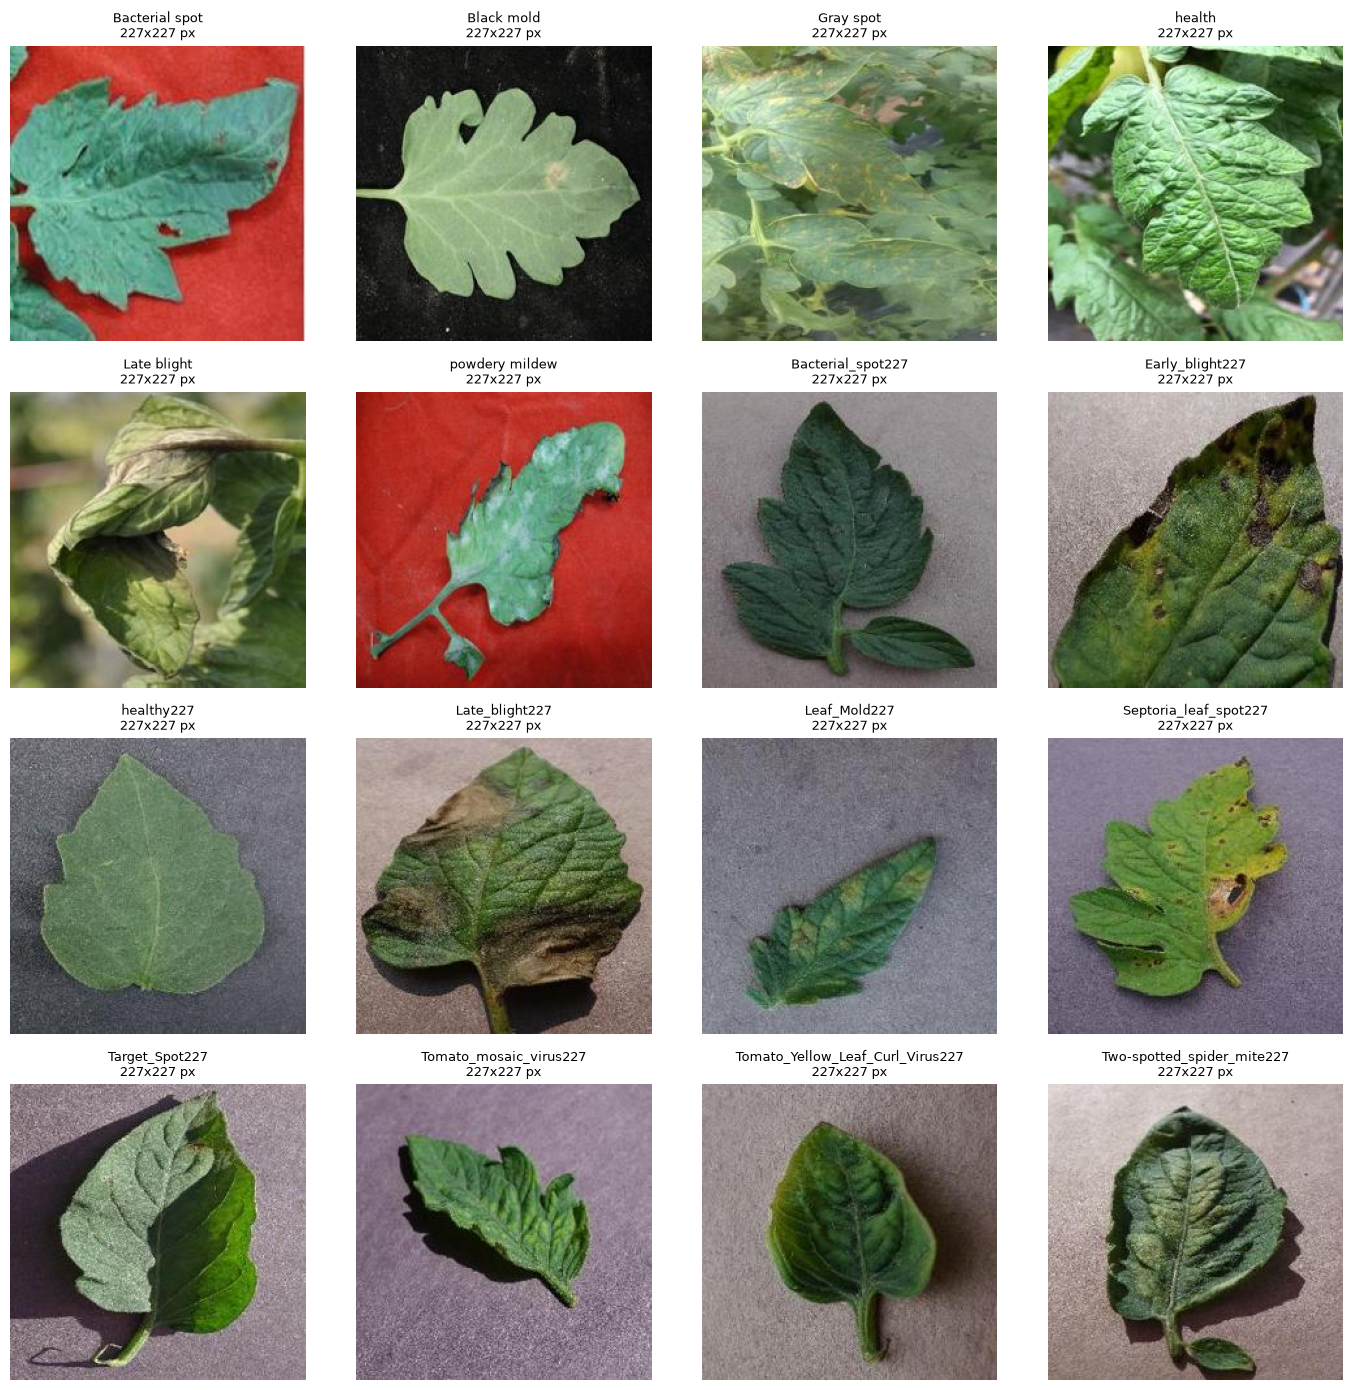

In [7]:
mostrar_grid_por_clase(df_meta)

In [8]:
# Ejecución del resumen
df_categorias = resumir_categorias_dataset('./data')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df_categorias)

,No Preprocesada,Preprocesada,Train,Test,Sin Split,Total_Imagenes
Categoria,,,,,,
Bacterial spot,880,110,792,198,0,990
Bacterial_spot227,8510,1702,6808,1702,1702,10212
Black mold,536,67,481,122,0,603
Early_blight227,4000,800,3200,800,800,4800
Gray spot,672,84,604,152,0,756
Late blight,784,98,705,177,0,882
Late_blight227,7640,1528,6112,1528,1528,9168
Leaf_Mold227,3810,762,3048,762,762,4572
Septoria_leaf_spot227,7085,1417,5668,1417,1417,8502


Confirmamos la hipótesis anterior: Acorde a la documentación existen alrededor de 19 k fotos. Sin embargo, podemos notar que únicamente para `Tomato_Yellow_Leaf_Curl_Virus227`se leen más de 25 k. Leeremos únicamente las fotos de `plantvillage/Preprocessed data` y `taiwan/data augmentation`

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"> </span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Transformación</span></div>

 ## Decisiones de transformación
 
1. **Aplanar imágenes posterior a escala de grises y en 64x64:** Se conservan todos los pixeles de imágenes después de pasarlas a escala de grises y a dimensiones de 64x64.
2. **Escalado StandardScaler (para PCA y t-SNE):** se estandarizan los datos (media 0, varianza 1) antes de aplicar PCA y t-SNE como buena práctica para ambos algoritmos. Una vez transformados los datos, evaluaremos de cualquier modo las distribuciones para confirmar su uso.
3. **Escalado MinMaxScaler (para NMF):** Sabemos que NMF requiere valores no negativos; como las imágenes se aplanan a partir de intensidades de píxel en escala de grises (siempre no negativas), esto se cumple de forma natural, sin embargo, se dividirá sobre 255 para obtener escala [0,1].
4. **Separación de train y test:** Dado que el dataset de Taiwan tiene imágenes generadas artificialmente y ya viene separado en Train y Test, se mantendrá esa distribución usando los metadatos ANTES de escalar. Por lo mismo, se separa Plantvillage antes de escalar.
5. **Resultados de dataframes:** Se obtendrán dos dataframes con los que trabajar, uno solo con características (resultado del punto 1) y otro con metadatos de esas imágenes para conservar las etiquetas. 

In [9]:
def extraer_metadatos_ruta(ruta_img, ruta_base):
    """ 
    Función que resume los metadatos por imagen (indica el split de entrenamiento/prueba
    y la categoría a la que pertenece).

    Args:
        ruta_img (str): Dirección completa de la imagen que permite deducir parte de los metadatos
        ruta_base (str): Dirección de la carpeta origen.

    Returns:
        dict: Metadatos semiestructurados.
    """
    partes_lower = [p.lower() for p in ruta_img.relative_to(ruta_base).parts]
    if 'train' in partes_lower:
        split = 'Train' # Identificamos si se encuentra en un folder de train o test
    elif 'test' in partes_lower:
        split = 'Test'
    else:
        split = 'Sin Split'

    categoria = ruta_img.parent.name

    return {
        'split': split,
        'categoria': categoria,
    }


In [10]:
def cargar_dataset_aplanado(base_dir, nombre_dataset, tam_img=(64, 64), extensiones=None, mostrar_progreso=True):
    """ 
    Función principal de carga de datos. Carga cada imagen presente en la carpeta, la convierte a
    escala de grises, la redimensiona a `tam_img` y la aplana a un vector, además de recopilar
    los metadatos de cada registro individual a través de la función anterior.

    Args:
        base_dir (str): Dirección de la carpeta que contiene toda la información
        nombre_dataset (str): Información del dataset de origen
        tam_img (tuple, (64, 64) predeterminado): Resolución deseada para el redimensionado.
        extensiones (dict, None predeterminado): Tipos de archivos a leer.
        mostrar_progreso (bool, True predeterminado): Para modificar si se muestra el progreso de carga o no
    
    Returns:
        X (np.ndarray): Array con todos los registros aplanados y listos para someter a transformación.
        df_meta (pd.DataFrame): DataFrame con los metadatos ('ruta', 'split', 'categoria') de cada registro.
    """
    if extensiones is None:
        extensiones = {'.jpg', '.jpeg', '.png', '.bmp'}

    ruta_base = Path(base_dir)
    rutas_img = [p for p in ruta_base.rglob('*') if p.suffix.lower() in extensiones]
    n = len(rutas_img)

    if n == 0:
        raise ValueError(f"No se encontraron imágenes en {base_dir}")

    iterador = rutas_img
    if mostrar_progreso:
        try:
            from tqdm import tqdm
            iterador = tqdm(rutas_img, desc=f'Procesando {nombre_dataset}')
        except ImportError:
            pass

    features = []
    registros = []
    for ruta_img in iterador:
        try:
            with Image.open(ruta_img) as img:
                img_gris = img.convert('L') # Escala de grises
                img_gris = img_gris.resize(tam_img, Image.Resampling.LANCZOS) # Redimensionado
                arr = np.asarray(img_gris, dtype=np.uint8)

            vector = arr.flatten() # Aplanado a vector
            features.append(vector)

            meta = extraer_metadatos_ruta(ruta_img, ruta_base)
            meta['ruta'] = str(ruta_img)
            registros.append(meta)
        except Exception as e:
            print(f"Imagen omitida por error ({ruta_img}): {e}")

    X = np.array(features, dtype=np.float64)
    df_meta = pd.DataFrame(registros)[['ruta', 'split', 'categoria']]

    return X, df_meta


In [11]:
X_plantvillage, meta_plantvillage = cargar_dataset_aplanado('./data/plantvillage/Preprocessed data', nombre_dataset='plantvillage')
X_taiwan, meta_taiwan = cargar_dataset_aplanado('./data/taiwan/data augmentation', nombre_dataset='taiwan')

print("PlantVillage: ", X_plantvillage.shape, "-> filas:", len(meta_plantvillage))
print("Taiwan: ", X_taiwan.shape, "-> filas:", len(meta_taiwan))

display(meta_plantvillage.head())
display(meta_taiwan.head())


Procesando plantvillage:   0%|          | 0/14531 [00:00<?, ?it/s]


Procesando plantvillage:   1%|          | 133/14531 [00:00<00:10, 1322.76it/s]


Procesando plantvillage:   2%|▏         | 266/14531 [00:00<00:10, 1317.86it/s]


Procesando plantvillage:   3%|▎         | 398/14531 [00:00<00:10, 1317.66it/s]


Procesando plantvillage:   4%|▎         | 530/14531 [00:00<00:10, 1313.33it/s]

...


Procesando taiwan:  99%|█████████▊| 4902/4976 [00:03<00:00, 1261.29it/s]


Procesando taiwan: 100%|██████████| 4976/4976 [00:03<00:00, 1259.15it/s]

PlantVillage:  (14531, 4096) -> filas: 14531
Taiwan:  (4976, 4096) -> filas: 4976


,ruta,split,categoria
0,data\plantvillage\Preprocessed data\Bacterial_...,Sin Split,Bacterial_spot227
1,data\plantvillage\Preprocessed data\Bacterial_...,Sin Split,Bacterial_spot227
2,data\plantvillage\Preprocessed data\Bacterial_...,Sin Split,Bacterial_spot227
3,data\plantvillage\Preprocessed data\Bacterial_...,Sin Split,Bacterial_spot227
4,data\plantvillage\Preprocessed data\Bacterial_...,Sin Split,Bacterial_spot227


,ruta,split,categoria
0,data\taiwan\data augmentation\Train\Bacterial ...,Train,Bacterial spot
1,data\taiwan\data augmentation\Train\Bacterial ...,Train,Bacterial spot
2,data\taiwan\data augmentation\Train\Bacterial ...,Train,Bacterial spot
3,data\taiwan\data augmentation\Train\Bacterial ...,Train,Bacterial spot
4,data\taiwan\data augmentation\Train\Bacterial ...,Train,Bacterial spot


In [12]:
# Limpieza del texto de la columna 'categoria': quitamos el sufijo '227', cambiamos '_' por ' ' y recortamos espacios
for meta in (meta_plantvillage, meta_taiwan):
    meta['categoria'] = meta['categoria'].str.replace('227', '', regex=False).str.replace('_', ' ', regex=False).str.strip()

display(meta_plantvillage['categoria'].unique())
display(meta_taiwan['categoria'].unique())

<StringArray>
[               'Bacterial spot',                  'Early blight',
                       'healthy',                   'Late blight',
                     'Leaf Mold',            'Septoria leaf spot',
                   'Target Spot',           'Tomato mosaic virus',
 'Tomato Yellow Leaf Curl Virus',       'Two-spotted spider mite']
Length: 10, dtype: str

<StringArray>
['Bacterial spot',     'Black mold',      'Gray spot',         'health',
    'Late blight', 'powdery mildew']
Length: 6, dtype: str

In [13]:
def eliminar_duplicados(X, df_meta):
    """
    Elimina las filas duplicadas de la matriz de características X y sincroniza el
    DataFrame de metadatos asociado usando los índices de las filas conservadas, de
    forma que X y df_meta queden alineados uno a uno.

    Args:
        X (np.ndarray): Matriz de características, una fila por imagen.
        df_meta (pd.DataFrame): Metadatos de cada imagen, en el mismo orden que X.

    Returns:
        X_unico (np.ndarray): Matriz de características sin duplicados.
        df_meta_unico (pd.DataFrame): Metadatos sincronizados con X_unico.
    """
    mascara_unicos = ~pd.DataFrame(X).duplicated(keep='first').to_numpy()
    X_unico = X[mascara_unicos]
    df_meta_unico = df_meta.loc[mascara_unicos].reset_index(drop=True)
    return X_unico, df_meta_unico

n_plant_antes, n_taiwan_antes = len(meta_plantvillage), len(meta_taiwan)

X_plantvillage, meta_plantvillage = eliminar_duplicados(X_plantvillage, meta_plantvillage)
X_taiwan, meta_taiwan = eliminar_duplicados(X_taiwan, meta_taiwan)

print(f"PlantVillage: {n_plant_antes - len(meta_plantvillage)} duplicados eliminados -> {X_plantvillage.shape}")
print(f"Taiwan: {n_taiwan_antes - len(meta_taiwan)} duplicados eliminados -> {X_taiwan.shape}")

PlantVillage: 10 duplicados eliminados -> (14521, 4096)
Taiwan: 0 duplicados eliminados -> (4976, 4096)


In [ ]:
# Persistir a disco para no repetir el procesamiento cada vez
np.save('X_plantvillage.npy', X_plantvillage)
np.save('X_taiwan.npy', X_taiwan)

In [ ]:
X_plantvillage = np.load('X_plantvillage.npy')
X_taiwan = np.load('X_taiwan.npy')
df_plantvillage = pd.DataFrame(X_plantvillage)
df_taiwan = pd.DataFrame(X_taiwan)

	PLANTVILLAGE
Número de registros: 14521
Número de columnas: 4097
----------------------------------------------------------------------------------------------------
Valores nulos: 0


Valores duplicados: 0
----------------------------------------------------------------------------------------------------
Mostrando boxplots de una muestra aleatoria de 25 de 4096 columnas numéricas totales.


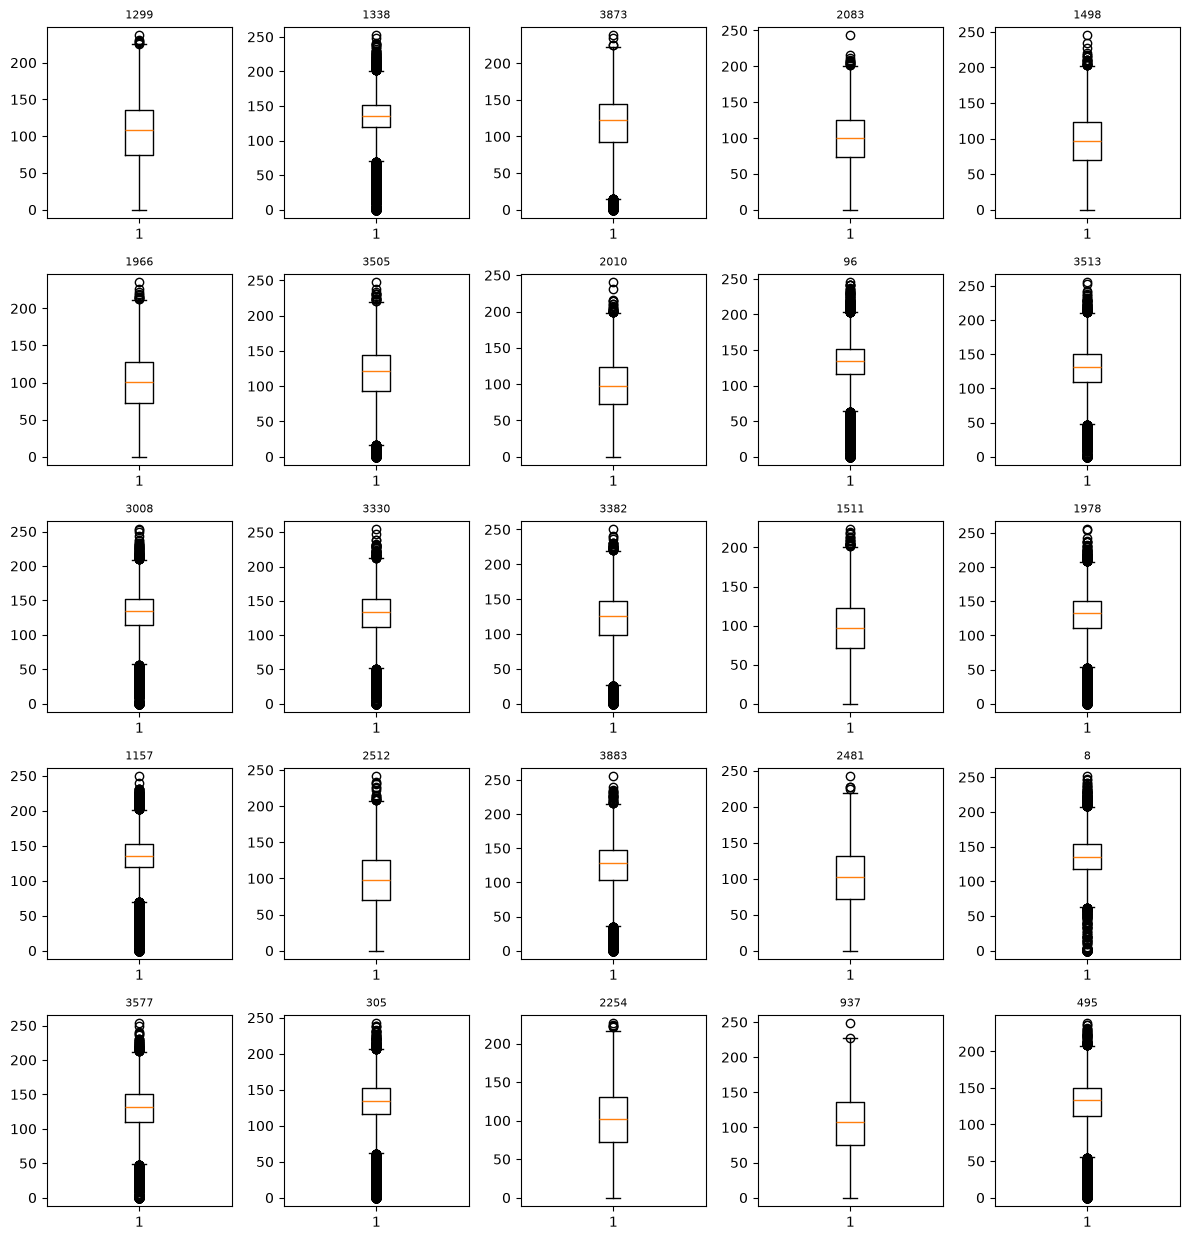

Estadísticas descriptivas:


,1299,1338,3873,2083,1498,1966,3505,2010,96,3513,3008,3330,3382,1511,1978,1157,2512,3883,2481,8,3577,305,2254,937,495
count,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000,14521.000000
mean,104.687143,132.936506,117.117760,99.360581,96.410784,99.657186,116.093107,97.640658,130.975277,127.298671,130.894222,129.980718,120.502376,97.243716,126.065560,133.620136,97.600303,123.103918,100.864748,135.030576,127.940431,131.911783,100.697335,105.109359,127.916121
std,41.254448,33.179493,39.819568,35.586220,36.913491,39.479174,40.059285,35.545171,35.132914,35.802944,33.658815,33.684074,39.492621,36.985877,38.638802,32.681741,39.105838,37.292892,40.878728,30.498587,35.279585,33.056603,40.679946,41.479598,35.793119
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.000000,119.000000,93.000000,74.000000,70.000000,72.000000,93.000000,73.000000,116.000000,109.000000,114.000000,112.000000,99.000000,71.000000,111.000000,119.000000,70.000000,103.000000,72.000000,117.000000,110.000000,116.000000,72.000000,75.000000,112.000000
50%,108.000000,136.000000,123.000000,100.000000,96.000000,101.000000,122.000000,98.000000,135.000000,131.000000,134.000000,133.000000,126.000000,97.000000,133.000000,136.000000,98.000000,128.000000,103.000000,135.000000,131.000000,135.000000,102.000000,108.000000,133.000000
75%,135.000000,152.000000,145.000000,125.000000,123.000000,128.000000,144.000000,123.000000,151.000000,150.000000,152.000000,152.000000,147.000000,123.000000,150.000000,152.000000,125.000000,148.000000,131.000000,153.000000,151.000000,152.000000,130.000000,136.000000,150.000000
max,237.000000,252.000000,238.000000,243.000000,245.000000,235.000000,247.000000,240.000000,245.000000,255.000000,253.000000,254.000000,250.000000,223.000000,255.000000,249.000000,241.000000,255.000000,242.000000,251.000000,253.000000,242.000000,226.000000,248.000000,238.000000


	TAIWAN
Número de registros: 4976
Número de columnas: 4097
----------------------------------------------------------------------------------------------------
Valores nulos: 0


Valores duplicados: 0
----------------------------------------------------------------------------------------------------
Mostrando boxplots de una muestra aleatoria de 25 de 4096 columnas numéricas totales.


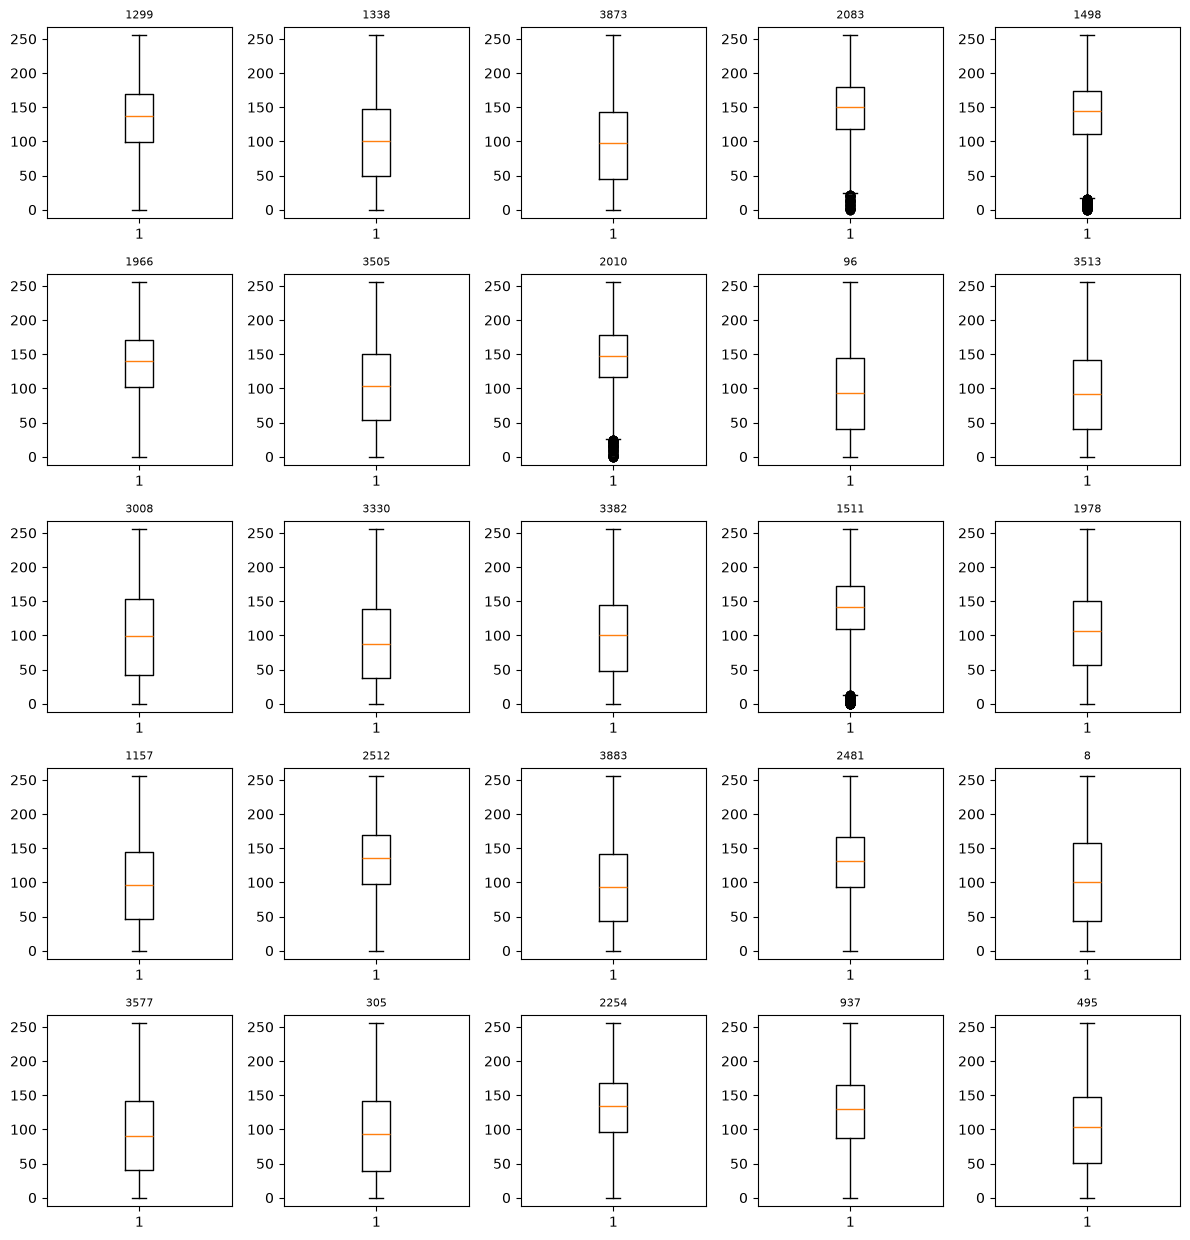

Estadísticas descriptivas:


,1299,1338,3873,2083,1498,1966,3505,2010,96,3513,3008,3330,3382,1511,1978,1157,2512,3883,2481,8,3577,305,2254,937,495
count,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000,4976.000000
mean,132.679662,101.248392,97.809887,147.768891,141.451166,134.997387,102.940514,145.604703,96.343449,95.389871,103.213424,93.274719,99.641881,139.659365,105.926045,99.002814,131.442725,96.296222,127.685892,104.918207,94.434686,95.458601,129.649920,124.893288,102.300241
std,54.332783,62.971192,62.178211,46.447572,48.915766,52.205753,61.625793,46.821216,64.503154,62.839807,69.780986,63.861948,62.100929,49.346054,62.726547,62.678537,53.924193,63.121724,55.529564,70.896501,63.168704,63.500655,54.402103,56.942620,62.736429
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,49.000000,45.000000,118.000000,111.000000,102.000000,54.000000,117.000000,40.000000,41.000000,42.000000,37.000000,47.750000,109.000000,56.000000,47.000000,98.000000,43.000000,93.000000,43.000000,40.000000,39.750000,96.000000,88.000000,51.000000
50%,136.500000,101.000000,97.000000,150.000000,145.000000,140.000000,104.000000,147.000000,93.000000,92.000000,99.000000,88.000000,100.000000,142.000000,107.000000,96.000000,135.000000,93.000000,132.000000,100.000000,91.000000,93.000000,134.000000,130.000000,103.000000
75%,169.000000,147.000000,143.000000,180.000000,174.000000,171.000000,150.000000,178.000000,144.000000,142.000000,153.000000,138.000000,145.000000,173.000000,151.000000,145.000000,169.000000,141.000000,167.000000,157.000000,141.250000,141.000000,168.000000,165.000000,147.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [16]:
def perfilado_general_muestra(df, n_muestra=30, random_state=42):
    """
    Genera un perfilado exploratorio de un DataFrame de alta dimensionalidad,
    mostrando boxplots de una muestra aleatoria de columnas numéricas.

    Args:
        df (pd.DataFrame): DataFrame a perfilar 
        n_muestra (int): número de columnas numéricas a graficar en los
            boxplots. Default 30.
        random_state (int): semilla para la selección aleatoria de columnas,
            para reproducibilidad.

    Returns:
        None: la función imprime y despliega los resultados directamente
        (no retorna ningún objeto).
    """
    n, m = df.shape
    print(f'Número de registros: {n}')
    print(f'Número de columnas: {m}')
    print('-' * 100)
    print(f'Valores nulos: {df.isna().sum().sum()}')
    print(f'Valores duplicados: {df.duplicated().sum()}')
    print('-' * 100)

    cols_numericas = df.select_dtypes(include=('float64', 'int64')).columns
    cols_muestra = pd.Series(cols_numericas).sample(
        n=min(n_muestra, len(cols_numericas)), random_state=random_state
    )

    print(f'Mostrando boxplots de una muestra aleatoria de {len(cols_muestra)} '
          f'de {len(cols_numericas)} columnas numéricas totales.')

    col_num = len(cols_muestra)
    plt.figure(figsize=(12, mt.ceil(col_num / 5) * 2.5))
    for i, column in enumerate(cols_muestra):
        plt.subplot(mt.ceil(col_num / 5), 5, i + 1)
        plt.boxplot(df[column])
        plt.title(column, fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Estadísticas descriptivas:')
    display(df[cols_muestra].describe())

print('\tPLANTVILLAGE')
perfilado_general_muestra(df_plantvillage, n_muestra= 25)
print('\tTAIWAN')
perfilado_general_muestra(df_taiwan, n_muestra= 25)

In [ ]:
# Escalado de características para NMF: de intensidades [0, 255] a [0, 1]
X_plantvillage_mm = X_plantvillage / 255.0
X_taiwan_mm = X_taiwan / 255.0

# Escalado de características para PCA y t-SNE: estandarización a media 0 y desviación estándar 1


## Resultados de transformación

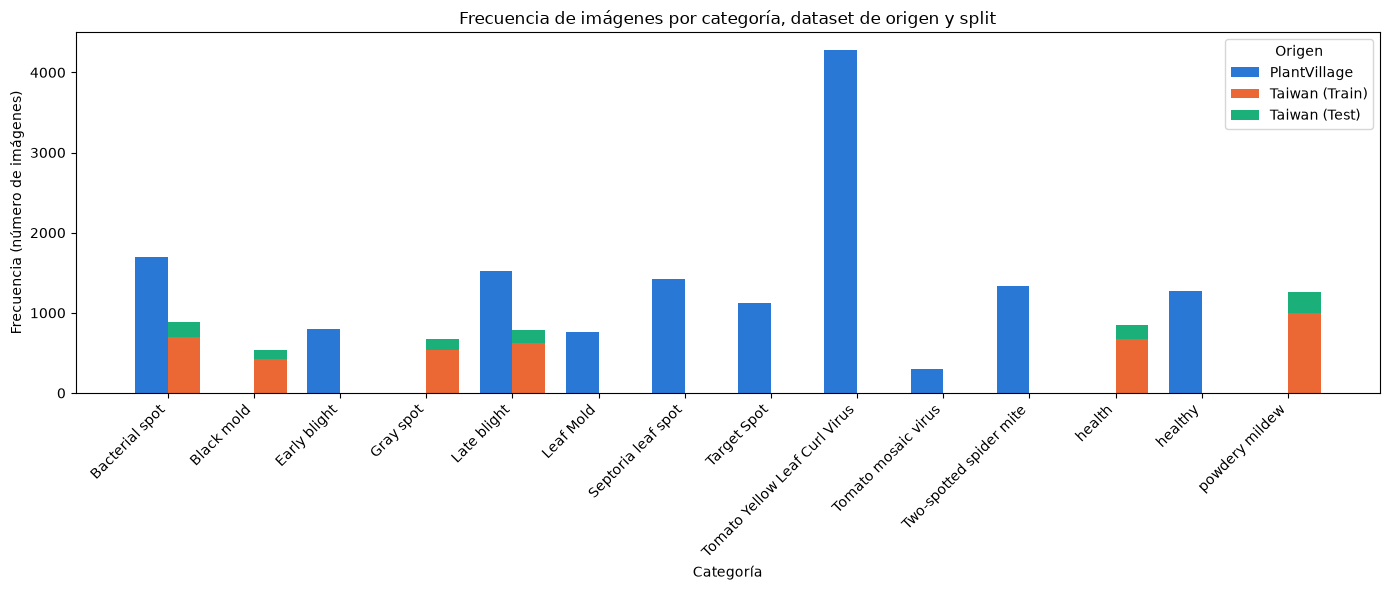

In [17]:
# Frecuencia de imágenes por categoría, dataset de origen (plantvillage/taiwan) y split (train/test en taiwan)
categorias_todas = sorted(set(meta_plantvillage['categoria']) | set(meta_taiwan['categoria']))

conteo_plant = meta_plantvillage['categoria'].value_counts().reindex(categorias_todas, fill_value=0)
conteo_taiwan_train = meta_taiwan.loc[meta_taiwan['split'] == 'Train', 'categoria'].value_counts().reindex(categorias_todas, fill_value=0)
conteo_taiwan_test = meta_taiwan.loc[meta_taiwan['split'] == 'Test', 'categoria'].value_counts().reindex(categorias_todas, fill_value=0)

x = np.arange(len(categorias_todas))
ancho = 0.38

plt.figure(figsize=(14, 6))
plt.bar(x - ancho / 2, conteo_plant.values, width=ancho, label='PlantVillage', color='#2a78d6')
plt.bar(x + ancho / 2, conteo_taiwan_train.values, width=ancho, label='Taiwan (Train)', color='#eb6834')
plt.bar(x + ancho / 2, conteo_taiwan_test.values, width=ancho, bottom=conteo_taiwan_train.values, label='Taiwan (Test)', color='#1baf7a')

plt.xlabel('Categoría')
plt.ylabel('Frecuencia (número de imágenes)')
plt.title('Frecuencia de imágenes por categoría, dataset de origen y split')
plt.xticks(x, categorias_todas, rotation=45, ha='right')
plt.legend(title='Origen')
plt.tight_layout()
plt.show()

In [46]:
display(df_plantvillage.sample(5))
display(df_taiwan.sample(5))

0      1      2      3      4      5      6      7      8      9     \
5982   143.0  140.0  138.0  136.0  146.0  146.0  143.0  142.0  142.0  140.0   
8275   106.0  122.0  119.0  114.0  132.0  123.0  111.0  122.0  120.0  121.0   
12609  152.0  150.0  150.0  147.0  144.0  146.0  148.0  147.0  145.0  144.0   
14221  134.0  139.0  134.0  137.0  143.0  141.0  143.0  149.0  148.0  149.0   
3746   167.0  141.0  122.0  148.0  127.0  128.0  149.0  126.0  136.0  143.0   

        10     11     12     13     14     15     16     17     18     19    \
5982   143.0  144.0  141.0  144.0  142.0  140.0  141.0  141.0  142.0  143.0   
8275   118.0  117.0  121.0  120.0  125.0  135.0  137.0  133.0  131.0  127.0   
12609  144.0  141.0  140.0  142.0  145.0  142.0  136.0  136.0  141.0  143.0   
14221  135.0  139.0  135.0  141.0  140.0  126.0  116.0  127.0  125.0  112.0   
3746   136.0  102.0  121.0  109.0  107.0  127.0  138.0  136.0  133.0  132.0   

        20     21     22     23     24     25     26     27     28     29    \
5982   143.0  144.0  141.0  145.0  144.0  146.0  143.0  142.0  138.0  133.0   
8275   141.0  146.0  128.0  135.0  156.0  134.0  126.0  140.0  126.0  133.0   
12609  144.0  143.0  141.0  141.0  142.0  138.0  136.0  136.0  137.0  135.0   
14221  117.0  130.0  128.0  118.0  116.0  116.0  117.0  112.0  119.0  123.0   
3746   132.0  136.0  140.0  138.0  134.0  136.0  126.0  130.0  131.0  120.0   

        30     31     32     33     34     35     36     37     38     39    \
5982   137.0  141.0  137.0  143.0  141.0  140.0  139.0  136.0  136.0  138.0   
8275   146.0  151.0  148.0  151.0  146.0  143.0  147.0  140.0  147.0  141.0   
12609  131.0  130.0  134.0  134.0  132.0  128.0  128.0  129.0  129.0  128.0   
14221  115.0  124.0  122.0  119.0  116.0  118.0  115.0  128.0  128.0  124.0   
3746   117.0  113.0  128.0  148.0  127.0  116.0  124.0  109.0  110.0  125.0   

        40     41     42     43     44     45     46     47     48     49    \
5982   134.0  127.0  133.0  134.0  135.0  131.0  134.0  134.0  137.0  133.0   
8275   142.0  148.0  146.0  146.0  152.0  156.0  155.0  155.0  161.0  157.0   
12609  125.0  122.0  123.0  124.0  123.0  124.0  122.0  116.0  115.0  118.0   
14221  127.0  125.0  126.0  123.0  122.0  115.0  120.0  126.0  125.0  124.0   
3746   129.0  121.0  141.0  128.0  118.0  147.0  133.0  128.0  108.0  119.0   

        50     51     52     53     54     55     56     57     58     59    \
5982   142.0  139.0  135.0  132.0  133.0  135.0  133.0  135.0  131.0  128.0   
8275   156.0  170.0  157.0  158.0  160.0  165.0  169.0  169.0  167.0  171.0   
12609  123.0  125.0  116.0  112.0  114.0  112.0  111.0  111.0  112.0  110.0   
14221  125.0  129.0  122.0  126.0  121.0  123.0  133.0  127.0  123.0  127.0   
3746   117.0  114.0  128.0  114.0  127.0  145.0  120.0  128.0  129.0  135.0   

        60     61     62     63     64     65     66     67     68     69    \
5982   138.0  143.0  138.0  135.0  147.0  140.0  144.0  141.0  145.0  142.0   
8275   167.0  174.0  172.0  170.0  112.0  120.0  119.0  114.0  128.0  121.0   
12609  113.0  116.0  114.0  113.0  151.0  150.0  151.0  150.0  148.0  146.0   
14221  128.0  116.0  113.0  116.0  135.0  146.0  138.0  134.0  133.0  144.0   
3746   115.0  123.0  132.0  128.0  145.0  136.0  119.0  122.0  141.0  143.0   

        70     71     72     73     74     75     76     77     78     79    \
5982   142.0  140.0  142.0  142.0  139.0  143.0  144.0  144.0  141.0  145.0   
8275   113.0  122.0  131.0  133.0  120.0  130.0  129.0  124.0  137.0  126.0   
12609  145.0  145.0  145.0  144.0  144.0  142.0  142.0  140.0  141.0  141.0   
14221  138.0  143.0  145.0  139.0  135.0  135.0  130.0  135.0  139.0  129.0   
3746   129.0  128.0  130.0  122.0  141.0  118.0  123.0  130.0  120.0  150.0   

        80     81     82     83     84     85     86     87     88     89    \
5982   143.0  143.0  143.0  143.0  137.0  144.0  146.0  141.0  140.0  142.0   
8275   128.0  133.0  132.0  136.0  130.0  148.0  1

0      1      2      3      4      5      6      7      8      9     \
3205  245.0  241.0  246.0  249.0  234.0  226.0  237.0  236.0  206.0  138.0   
3464  209.0  215.0  227.0  241.0  241.0  240.0  243.0  243.0  242.0  242.0   
3146  151.0  149.0  120.0   59.0   75.0   71.0   72.0   45.0   36.0   46.0   
2077  128.0  135.0  110.0  110.0  129.0  113.0   88.0  124.0  137.0  139.0   
4818   37.0   22.0   11.0   10.0   27.0   52.0   78.0  105.0  126.0  128.0   

       10     11     12     13     14     15     16     17     18     19    \
3205  135.0  155.0  161.0  158.0  138.0  131.0  133.0  168.0  172.0  161.0   
3464  241.0  241.0  248.0  217.0  213.0  251.0  251.0  249.0  249.0  254.0   
3146   99.0  114.0  121.0  123.0  124.0  130.0  133.0  135.0  139.0  146.0   
2077  128.0  121.0  143.0  150.0  148.0  159.0  159.0  154.0  166.0  179.0   
4818  117.0  102.0   87.0   80.0   79.0   81.0   77.0   66.0   64.0   59.0   

       20     21     22     23     24     25     26     27     28     29    \
3205  169.0  161.0  130.0  127.0  139.0  139.0  172.0  209.0  172.0   97.0   
3464  254.0  255.0  255.0  254.0  254.0  245.0  148.0  106.0  127.0  137.0   
3146  142.0  141.0  148.0  150.0  149.0  160.0  159.0  150.0  144.0  136.0   
2077  167.0  159.0  158.0  146.0  140.0  135.0   96.0   84.0   85.0   83.0   
4818   56.0   49.0   41.0   37.0   38.0   38.0   37.0   44.0   49.0   52.0   

       30     31     32     33     34     35     36     37     38     39    \
3205   84.0  120.0  151.0  138.0  115.0  136.0  151.0  144.0  148.0  134.0   
3464  118.0  137.0  167.0  169.0  123.0  131.0  142.0  147.0  146.0  141.0   
3146  132.0  123.0  108.0  109.0  108.0  113.0   93.0   67.0   73.0   61.0   
2077   80.0   80.0   56.0   42.0   56.0   44.0   76.0   78.0   24.0  174.0   
4818   54.0   54.0   57.0   58.0   60.0   65.0   64.0   56.0   56.0   58.0   

       40     41     42     43     44     45     46     47     48     49    \
3205  127.0  139.0  147.0  142.0  141.0  147.0  143.0  139.0  153.0  141.0   
3464  146.0  148.0  142.0  143.0  149.0  150.0  152.0  153.0  151.0  150.0   
3146   45.0   61.0   72.0   42.0   36.0   73.0   69.0   61.0   73.0   74.0   
2077  255.0  193.0   99.0   69.0   90.0   91.0   85.0  131.0  171.0  172.0   
4818   57.0   54.0   62.0   63.0   67.0   74.0   79.0   82.0   86.0   93.0   

       50     51     52     53     54     55     56     57     58     59    \
3205  142.0  142.0  134.0  127.0  125.0  132.0  146.0  132.0  138.0  158.0   
3464  148.0  180.0  183.0  150.0  149.0  150.0  153.0  153.0  163.0  159.0   
3146   69.0   66.0   63.0   60.0   66.0   69.0   73.0   75.0   62.0   77.0   
2077  188.0  177.0  160.0  161.0  185.0  187.0  163.0  150.0  173.0  198.0   
4818   95.0   90.0   82.0   83.0   67.0   61.0   56.0   56.0   58.0   49.0   

       60     61     62     63     64     65     66     67     68     69    \
3205  163.0  164.0  137.0   81.0  246.0  239.0  239.0  244.0  230.0  205.0   
3464  155.0  154.0  158.0  160.0  186.0  238.0  240.0  238.0  241.0  238.0   
3146   68.0   61.0   61.0   55.0  149.0  148.0  120.0   59.0   73.0   71.0   
2077  198.0  175.0  174.0  187.0  169.0  153.0  128.0  106.0  115.0   98.0   
4818   67.0   82.0   75.0   72.0   32.0   15.0   11.0   20.0   45.0   74.0   

       70     71     72     73     74     75     76     77     78     79    \
3205  202.0  207.0  189.0  146.0  121.0  143.0  161.0  161.0  170.0  157.0   
3464  240.0  238.0  241.0  242.0  243.0  243.0  227.0  236.0  220.0  231.0   
3146   73.0   45.0   31.0   55.0  105.0  114.0  118.0  121.0  123.0  129.0   
2077   49.0   96.0  127.0  130.0  132.0  131.0  133.0  146.0  155.0  159.0   
4818  105.0  120.0  112.0  101.0   98.0   90.0   81.0   75.0   75.0   78.0   

       80     81     82     83     84     85     86     87     88     89    \
3205  138.0  160.0  170.0  149.0  126.0  119.0  129.0  133.0  129.0  120.0   
3464  250.0  248.0  252.0  255.0  254.0  255.0  255.0  254.0  255.0  236.0   
3146  130.0  132.0  1

In [19]:
display(meta_plantvillage.sample(5))
display(meta_taiwan.sample(5))

,ruta,split,categoria
4483,data\plantvillage\Preprocessed data\Late_bligh...,Sin Split,Late blight
2595,data\plantvillage\Preprocessed data\healthy227...,Sin Split,healthy
8609,data\plantvillage\Preprocessed data\Tomato_mos...,Sin Split,Tomato mosaic virus
12200,data\plantvillage\Preprocessed data\Tomato_Yel...,Sin Split,Tomato Yellow Leaf Curl Virus
10228,data\plantvillage\Preprocessed data\Tomato_Yel...,Sin Split,Tomato Yellow Leaf Curl Virus


,ruta,split,categoria
3478,data\taiwan\data augmentation\Train\powdery mi...,Train,powdery mildew
972,data\taiwan\data augmentation\Train\Black mold...,Train,Black mold
2804,data\taiwan\data augmentation\Train\Late bligh...,Train,Late blight
4821,data\taiwan\data augmentation\Test\powdery mil...,Test,powdery mildew
4920,data\taiwan\data augmentation\Test\powdery mil...,Test,powdery mildew


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. Aplicación de Algoritmos </span></div>

### PCA

### NMF

Buscando k óptimo NMF (PlantVillage):   0%|          | 0/5 [00:00<?, ?it/s]c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
Buscando k óptimo NMF (PlantVillage):  20%|██        | 1/5 [00:14<00:59, 14.97s/it]c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
Buscando k óptimo NMF (PlantVillage):  40%|████      | 2/5 [00:30<00:45, 15.31s/it]c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
Buscando k óptimo NMF (PlantVillage):  60%|██████    | 3/5 [00:46<00:31, 15

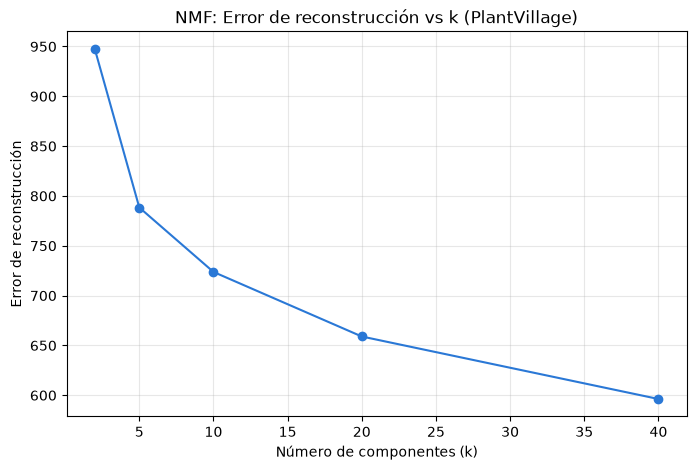

Buscando k óptimo NMF (Taiwan):   0%|          | 0/5 [00:00<?, ?it/s]c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
Buscando k óptimo NMF (Taiwan):  20%|██        | 1/5 [00:03<00:15,  3.85s/it]c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
Buscando k óptimo NMF (Taiwan):  40%|████      | 2/5 [00:08<00:12,  4.18s/it]c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
Buscando k óptimo NMF (Taiwan):  60%|██████    | 3/5 [00:12<00:08,  4.24s/it]c:\Users\PC\Docu

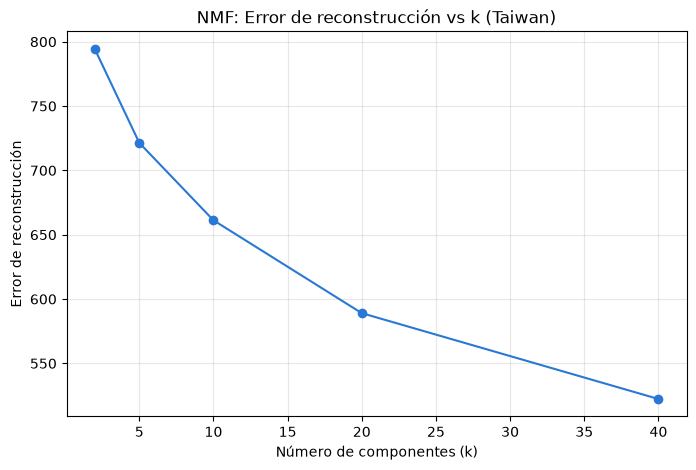

In [ ]:
def buscar_k_optimo_nmf(X_scaled, k_list, nombre_dataset):
    """
    Prueba distintos valores de n_components para NMF sobre X_scaled y registra el
    error de reconstrucción de cada uno, graficando la curva k vs error (codo) para
    apoyar la selección de un buen valor de k.

    Args:
        X_scaled (np.ndarray): Matriz de características ya escalada a [0, 1].
        k_list (list[int]): Valores de n_components a evaluar.
        nombre_dataset (str): Nombre del dataset, para el título de la gráfica.

    Returns:
        errores (list[float]): Error de reconstrucción (reconstruction_err_) por cada k de k_list.
    """
    errores = []
    for k in tqdm(k_list, desc=f'Buscando k óptimo NMF ({nombre_dataset})'):
        nmf = NMF(n_components=k, random_state=42)
        nmf.fit(X_scaled)
        errores.append(nmf.reconstruction_err_)

    plt.figure(figsize=(8, 5))
    plt.plot(k_list, errores, marker='o', color='#2a78d6')
    plt.xlabel('Número de componentes (k)')
    plt.ylabel('Error de reconstrucción')
    plt.title(f'NMF: Error de reconstrucción vs k ({nombre_dataset})')
    plt.grid(alpha=0.3)
    plt.show()

    return errores

k_list = [2, 5, 10, 20, 40]

errores_plantvillage = buscar_k_optimo_nmf(X_plantvillage_mm, k_list, 'PlantVillage')
errores_taiwan = buscar_k_optimo_nmf(X_taiwan_mm, k_list, 'Taiwan')

In [ ]:
k_optimo_plantvillage = 5
k_optimo_taiwan = 5

nmf_plantvillage = NMF(n_components=k_optimo_plantvillage, random_state=42)
W_plantvillage = nmf_plantvillage.fit_transform(X_plantvillage_mm)
H_plantvillage = nmf_plantvillage.components_

nmf_taiwan = NMF(n_components=k_optimo_taiwan, random_state=42)
W_taiwan = nmf_taiwan.fit_transform(X_taiwan_mm)
H_taiwan = nmf_taiwan.components_

print(f"PlantVillage: W {W_plantvillage.shape}, H {H_plantvillage.shape}")
print(f"Taiwan: W {W_taiwan.shape}, H {H_taiwan.shape}")

c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


PlantVillage: W (14521, 20), H (20, 4096)
Taiwan: W (4976, 20), H (20, 4096)


c:\Users\PC\Documents\IIMAS\Datos Masivos II\Tarea 1\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [41]:
def graficar_componentes_nmf(H, nombre_dataset, n_componentes=10, img_shape=(64, 64)):
    """
    Grafica las primeras `n_componentes` filas de la matriz H aprendida por NMF,
    reinterpretándolas como imágenes en escala de grises de tamaño `img_shape`.

    Args:
        H (np.ndarray): Matriz de componentes de NMF (n_components x n_features).
        nombre_dataset (str): Nombre del dataset, para el título de la figura.
        n_componentes (int, 10 predeterminado): Número de componentes a graficar.
        img_shape (tuple, (64, 64) predeterminado): Forma para reinterpretar cada componente como imagen.

    Returns:
        None: Muestra la cuadrícula de componentes, no retorna valores.
    """
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i in range(n_componentes):
        axes[i].imshow(H[i].reshape(img_shape), cmap='gray')
        axes[i].set_title(f'Componente {i + 1}')
        axes[i].axis('off')
    fig.suptitle(f'Primeras {n_componentes} componentes NMF ({nombre_dataset})')
    plt.tight_layout()
    plt.show()

graficar_componentes_nmf(H_plantvillage, 'PlantVillage', 20)
graficar_componentes_nmf(H_taiwan, 'Taiwan', 20)

NameError: name 'H_plantvillage' is not defined

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">5. Clasificadores </span></div>

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">6. Conclusiones </span></div>